# VIP - Elastic Net
Name: Dhairya Dhamani

# Imports & global setup
This section imports all required libraries and utilities for data handling, numerical computation, and machine-learning modeling. Dependencies are grouped logically to separate core scientific tools from modeling-specific components. Explicit imports improve reproducibility and make the computational environment transparent.

In [27]:
# ============================================================
# Imports & Global Setup
# ============================================================
# Core scientific stack
import numpy as np
import pandas as pd

# Utilities
from pathlib import Path
import pickle
from abc import ABC, abstractmethod

# Machine learning
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Plotting
import matplotlib.pyplot as plt


# Abstract Class
This section defines an abstract base class that specifies a common interface for forecasting models. By enforcing standardized fit, predict, evaluate, and persistence methods, the design ensures modularity and allows the Elastic Net model to be easily replaced or extended with alternative forecasting approaches.

In [28]:
# ============================================================
# Base Forecast Model
# ============================================================
class BaseForecastModel(ABC):
    """
    Abstract base class for forecasting models.
    Enforces a consistent interface across models.
    """
    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass

# Evaluation metrics
This section defines performance metrics used to assess forecast quality. Traditional statistical metrics (RMSE, MAE, R²) quantify numerical accuracy, while directional accuracy measures whether the model correctly predicts the sign of future returns. Including both types of metrics enables evaluation from both statistical and economic perspectives.

In [29]:
# ============================================================
# Evaluation Metrics
# ============================================================
def rmse(y, yhat):
    """Root Mean Squared Error"""
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    """Mean Absolute Error"""
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    """Coefficient of Determination"""
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    """
    Fraction of observations where predicted and true
    returns have the same sign.
    """
    return float(np.mean(np.sign(y) == np.sign(yhat)))


# Data loading & leakage-safe preprocessing
This section handles all raw data ingestion and temporal alignment. Monthly macroeconomic variables are loaded from FRED-MD and conservatively shifted forward to reflect real-world publication delays. These monthly values are then forward-filled to daily frequency to match the price data. This design prevents look-ahead bias and ensures that each observation only uses information that would have been available at the time of prediction.

Macroeconomic predictors are sourced from FRED-MD at monthly frequency and aligned to daily returns using a conservative timing assumption. Monthly data for period m is assumed observable only at the beginning of m+1, reflecting publication delays and preventing look-ahead bias.

Monthly variables are forward-filled only after becoming available, while WTI prices are kept at daily frequency to preserve market dynamics. This setup prioritizes realistic, deployable forecasting over optimistic in-sample performance.


In [30]:
# ============================================================
# Data Helpers (Leakage-Safe)
# ============================================================

def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """
    Load macroeconomic predictors from the FRED-MD database
    at their native monthly frequency.

    Key design choice:
    - We intentionally keep macro data at its original frequency
      to avoid artificial interpolation or smoothing that could
      introduce forward-looking bias.

    Parameters
    ----------
    path : Path
        File path to the FRED-MD CSV file.
    features : list[str]
        Subset of macro variables to include as predictors.

    Returns
    -------
    pd.DataFrame
        Monthly macroeconomic time series indexed by date.
    """
    # FRED-MD includes a metadata row that must be skipped
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})

    # Ensure proper datetime parsing for time-series alignment
    df["date"] = pd.to_datetime(df["date"])

    # Set date as index and sort to guarantee chronological order
    df = df.set_index("date").sort_index()

    # Return only selected features to control dimensionality
    return df[features].copy()


def monthly_to_daily_strict(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert monthly macroeconomic data to daily frequency
    in a strictly leakage-safe manner.

    Assumption (Conservative Information Timing):
    - Macro data for month m is assumed to become observable
      only at the *start of month m+1*.
    - This mirrors real-world release delays and prevents
      look-ahead bias in daily return forecasting.

    Method:
    - Shift monthly timestamps forward by one full month
    - Forward-fill values across daily dates
    - Drop initial NaNs introduced by the shift

    This approach intentionally sacrifices timeliness
    in favor of econometric validity.

    Parameters
    ----------
    df : pd.DataFrame
        Monthly macroeconomic data.

    Returns
    -------
    pd.DataFrame
        Daily macroeconomic predictors aligned with
        information availability constraints.
    """
    df = df.copy()

    # Shift index so month-m data becomes available at start of month m+1
    df.index = df.index + pd.offsets.MonthBegin(1)

    # Create a complete daily date range
    daily_idx = pd.date_range(
        df.index.min(),
        df.index.max(),
        freq="D"
    )

    # Forward-fill macro values once they become available
    return df.reindex(daily_idx).ffill().dropna()


def load_price(path: Path) -> pd.Series:
    """
    Load daily WTI crude oil price data.

    Design choice:
    - Prices are kept at daily frequency to preserve
      high-frequency market dynamics.
    - Sorting ensures correct temporal ordering before
      return construction.

    Parameters
    ----------
    path : Path
        File path to WTI futures price data.

    Returns
    -------
    pd.Series
        Daily WTI price series indexed by date.
    """
    px = pd.read_csv(path, parse_dates=["Date"])

    return (
        px.set_index("Date")["Price"]
          .sort_index()
    )


# Feature engineering
This section constructs predictive features from the aligned data. Lagged versions of macroeconomic variables capture delayed effects on commodity prices, while daily log returns summarize recent price dynamics. The forecast target is defined as a future log return over a specified horizon, ensuring scale-invariant and stationary behavior suitable for linear modeling.

Lagged macroeconomic features are created to capture delayed and persistent effects of economic conditions on oil prices. Log returns are used for both predictors and targets to stabilize variance and align with standard financial modeling practice. The target is defined as a forward return to ensure strict separation between inputs and future outcomes.

In [31]:
# ============================================================
# Feature Engineering
# ============================================================

def make_lagged_features(X: pd.DataFrame, L: int) -> pd.DataFrame:
    """
    Construct lagged versions of predictors to capture
    delayed macroeconomic effects and temporal dependence.
    """
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1
    ).dropna()


def daily_log_return(price: pd.Series) -> pd.Series:
    """
    Compute daily log returns, which are additive over time
    and more stable than raw price differences.
    """
    return np.log(price).diff().rename("ret_1d")


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """
    Define the forecasting target as the forward log return:
    y_t = log(P_{t+h}) - log(P_t)

    Ensures the model predicts future returns only.
    """
    price = price.astype(float)
    return (
        np.log(price.shift(-horizon)) - np.log(price)
    ).rename("y")


# Dataset construction
This section assembles the final modeling dataset. Lagged macro features are combined with contemporaneous daily returns to form an ARX-style feature matrix. Targets are aligned strictly in time, and observations are split into training, validation, and test sets using chronological boundaries. This ensures realistic out-of-sample evaluation and prevents information leakage across splits.

In [32]:
# ============================================================
# Dataset Builder
# ============================================================

def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    """
    Construct leakage-safe train, validation, and test datasets
    using time-based splits.
    """

    # Load macro data (monthly → daily, leakage-safe) and prices
    macro_m = load_macro_monthly(macro_file, features)
    macro_d = monthly_to_daily_strict(macro_m)
    price = load_price(price_file)

    # Align predictors and prices on common dates
    base = macro_d.join(price, how="inner").dropna()

    # Include contemporaneous return as an ARX-style term
    base["ret_1d"] = np.log(base["Price"]).diff()

    # Lag macro variables and returns to capture temporal dependence
    X_macro = make_lagged_features(base[features], lookback)
    X_price = make_lagged_features(base[["ret_1d"]], lookback)

    X = X_macro.join(X_price).dropna()

    # Forward return target (strictly future-looking)
    y = make_target(base["Price"], horizon=horizon)

    # Align features and target
    y = y.reindex(X.index).dropna()
    X = X.loc[y.index]

    # Time-based train / validation / test splits
    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    # Boolean masks for splits
    train = X.index <= train_end
    val = (X.index > train_end) & (X.index <= val_end)
    test = X.index > val_end

    return (
        X.loc[train], y.loc[train],
        X.loc[val],   y.loc[val],
        X.loc[test],  y.loc[test],
    )


# Elastic Net model
This section implements the Elastic Net regression model. Hyperparameters are selected using time-series cross-validation, with feature scaling performed independently within each fold to avoid leakage. The final model is refit on the full training data using the selected hyperparameters. Elastic Net is well-suited for high-dimensional macroeconomic data due to its ability to handle multicollinearity and perform automatic feature selection.

In [33]:
# ============================================================
# Elastic Net Forecast Model
# ============================================================
class ElasticNetForecastModel(BaseForecastModel):
    """
    Elastic Net model with time-series cross-validation
    and leakage-safe scaling.
    """
    def __init__(
        self,
        alphas = np.logspace(-2, 1, 10),  # 0.01 → 10
        l1_ratios = [0.2, 0.5, 0.8],      # L1/L2 tradeoff
        n_splits=5,
        max_iter = 20000,
    ):
        super().__init__("regression")
        self.alphas = alphas
        self.l1_ratios = l1_ratios
        self.n_splits = n_splits
        self.max_iter = max_iter
        self.scaler = None
        self.model = None
        self.best_params_ = None
        self.feature_names_ = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        """
        Select hyperparameters using expanding-window
        time-series cross-validation, then refit on all
        training data.
        """
        self.feature_names_ = list(X_train.columns)
        X = X_train.values
        y = y_train.values

        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        best_rmse = np.inf

        self.cv_results_ = []

        for a in self.alphas:
            for l1 in self.l1_ratios:
                rmses = []
                for tr, va in tscv.split(X):
                    # Scale using training fold only (no leakage)
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(X[tr])
                    Xva = sc.transform(X[va])

                    m = ElasticNet(alpha=a, l1_ratio=l1, max_iter=self.max_iter)
                    m.fit(Xtr, y[tr])
                    rmses.append(rmse(y[va], m.predict(Xva)))

                mean_rmse = np.mean(rmses)
                self.cv_results_.append({
                    "alpha": a,
                    "l1_ratio": l1,
                    "rmse": mean_rmse
                })

                if mean_rmse < best_rmse:
                    best_rmse = mean_rmse
                    self.best_params_ = {"alpha": a, "l1_ratio": l1, "cv_rmse": mean_rmse}

        # Final refit using optimal hyperparameters
        self.scaler = StandardScaler()
        Xs = self.scaler.fit_transform(X)
        self.model = ElasticNet(
            alpha=self.best_params_["alpha"],
            l1_ratio=self.best_params_["l1_ratio"],
            max_iter=self.max_iter,
            random_state=42
        )
        self.model.fit(Xs, y)
        return self

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X.values))

    def evaluate(self, X, y):
        p = self.predict(X)
        return {
            "rmse": rmse(y.values, p),
            "mae": mae(y.values, p),
            "r2": r2(y.values, p),
            "directional_acc": directional_accuracy(y.values, p),
        }

    def coef_table(self, top_n=20):
        """
        Return top-N coefficients by absolute magnitude.
        """
        df = pd.DataFrame({
            "feature": self.feature_names_,
            "coef": self.model.coef_
        })
        df["abs"] = df["coef"].abs()
        return df.sort_values("abs", ascending=False).head(top_n).drop(columns="abs")

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))

# Main execution block
This section orchestrates the full experiment. It specifies data paths, selected macroeconomic features, forecasting horizon, and model configuration. The pipeline is executed end-to-end, producing out-of-sample performance metrics and saving the trained model. Centralizing these controls ensures clarity, reproducibility, and ease of experimentation.

In [ ]:
if __name__ == "__main__":

    # File paths for macroeconomic predictors and WTI prices
    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")

    # Selected macroeconomic variables spanning real activity,
    # monetary policy, yield curve, credit spreads, and sentiment
    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    # Build leakage-safe train / validation / test datasets
    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        lookback=30,
        horizon=1
    )

    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

    # Fit Elastic Net model with time-series CV
    model = ElasticNetForecastModel()
    model.fit(Xtr, ytr)


    # Evaluate out-of-sample performance
    print("\nBest params:", model.best_params_)
    print("\nValidation:", model.evaluate(Xva, yva))
    print("\nTest:", model.evaluate(Xte, yte))

    # Inspect most influential predictors
    print("\nTop coefficients:")
    print(model.coef_table())

    # Persist trained model for reuse
    model.save("elasticnet_wti_30d.pkl")

Shapes: (7953, 960) (2635, 960) (215, 960)

Best params: {'alpha': np.float64(0.01), 'l1_ratio': 0.5, 'cv_rmse': np.float64(0.023600134281789836)}

Validation: {'rmse': 0.03087045206701859, 'mae': 0.018476710974024268, 'r2': -1.1556045509397705e-06, 'directional_acc': 0.5294117647058824}

Test: {'rmse': 0.020521767599021454, 'mae': 0.015157029224723098, 'r2': -0.001840276312667699, 'directional_acc': 0.4930232558139535}

Top coefficients:
            feature  coef
0         RPI_lag01   0.0
1     W875RX1_lag01   0.0
632     TB6MS_lag21  -0.0
633       GS1_lag21  -0.0
634       GS5_lag21  -0.0
635      GS10_lag21  -0.0
636       AAA_lag21  -0.0
637       BAA_lag21  -0.0
638  TB3SMFFM_lag21   0.0
639  TB6SMFFM_lag21   0.0
640    T1YFFM_lag21   0.0
641    T5YFFM_lag21  -0.0
642   T10YFFM_lag21  -0.0
643    AAAFFM_lag21  -0.0
644    BAAFFM_lag21  -0.0
645   EXSZUSx_lag21  -0.0
646   EXJPUSx_lag21  -0.0
647   EXUSUKx_lag21  -0.0
648   EXCAUSx_lag21   0.0
649    PPICMM_lag21  -0.0


# Plots

## Plot Coefficients Paths
We inspected Elastic Net coefficient paths across regularization strengths and found that coefficients remain near zero over a wide range of α, only activating marginally at very small penalty levels. Additionally, the optimizer converged in a single iteration, indicating that the gradient conditions were already satisfied at the origin. This suggests that, at a daily horizon, lagged macroeconomic variables and returns provide limited linear predictive signal, rather than indicating an optimization or implementation issue.

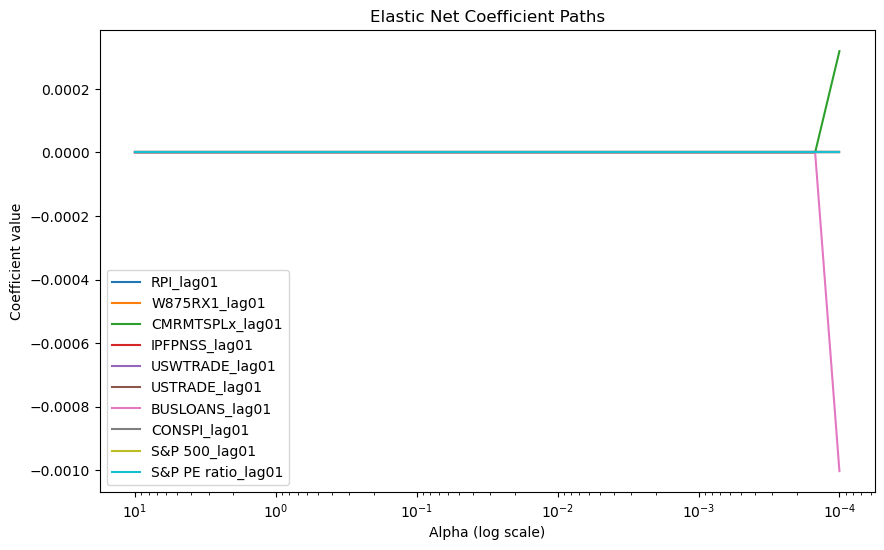

In [35]:
def plot_coef_paths(X, y, feature_names, l1_ratio=0.5):
    '''
    Plot coefficient paths for Elastic Net as alpha varies.
    '''
    alphas = np.logspace(-4, 1, 30)
    coefs = []

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # Compute coefficients for each alpha
    for a in alphas:
        model = ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=20000)
        model.fit(Xs, y)
        coefs.append(model.coef_)

    # Convert to NumPy array for easier indexing
    coefs = np.array(coefs)

    plt.figure(figsize=(10, 6))
    for i in range(min(10, coefs.shape[1])):  # plot top 10 only
        plt.plot(alphas, coefs[:, i], label=feature_names[i])

    plt.xscale("log")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("Coefficient value")
    plt.title("Elastic Net Coefficient Paths")
    plt.legend()
    plt.gca().invert_xaxis()
    plt.show()

plot_coef_paths(Xtr.values, ytr.values, Xtr.columns, l1_ratio=0.5)


## Plot CV loss v alpha
Coefficient stability across time-series folds was effectively zero, indicating that the optimizer converged to the same solution across splits. Additionally, cross-validated RMSE as a function of the regularization parameter α was largely flat, suggesting a weak gradient signal and limited sensitivity to regularization strength rather than numerical instability.

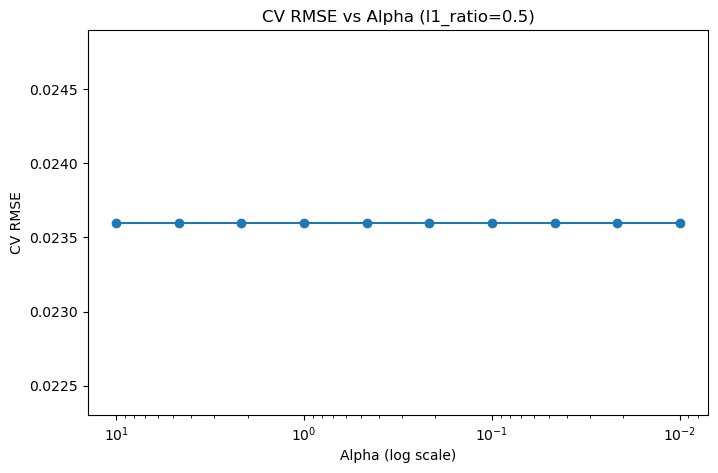

In [ ]:
# Plot CV RMSE vs Alpha for fixed l1_ratio
cv_df = pd.DataFrame(model.cv_results_)

# Fix one l1_ratio to visualize
l1 = model.best_params_["l1_ratio"]
df_plot = cv_df[cv_df["l1_ratio"] == l1]

plt.figure(figsize=(8, 5))
plt.plot(df_plot["alpha"], df_plot["rmse"], marker="o")
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Alpha (log scale)")
plt.ylabel("CV RMSE")
plt.title(f"CV RMSE vs Alpha (l1_ratio={l1})")
plt.show()


## Coefficient Stability
Coefficient stability across time-series folds was effectively zero, indicating that the optimizer converged to the same solution across splits. Additionally, cross-validated RMSE as a function of the regularization parameter α was largely flat, suggesting a weak gradient signal and limited sensitivity to regularization strength rather than numerical instability.

In [18]:
def coef_stability(X, y, l1_ratio, alpha):
    tscv = TimeSeriesSplit(5)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    coefs = []
    for tr, va in tscv.split(Xs):
        m = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000)
        m.fit(Xs[tr], y[tr])
        coefs.append(m.coef_)

    coefs = np.array(coefs)
    return np.std(coefs, axis=0)
np.mean(coef_stability(Xtr.values, ytr.values, 0.5, 0.01))

np.float64(0.0)

## Final Insights

This framework is designed not only to produce forecasts but also to assess the limits of predictability in energy markets. Results demonstrating weak or unstable performance are informative, highlighting the challenges of forecasting short-horizon commodity returns using linear macro-based models. Such findings align with existing literature and motivate alternative frequencies, horizons, or nonlinear approaches.

# Entire Code Block

In [4]:
# ============================================================
# Elastic Net Forecasting for WTI Futures (Next-Month Returns)
# ============================================================

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle

from abc import ABC, abstractmethod
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


# ============================================================
# Base Forecast Model (unchanged)
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass


# ============================================================
# Metrics
# ============================================================
def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    return float(np.mean(np.sign(y) == np.sign(yhat)))

# ============================================================
# Data helpers (STRICT leakage control)
# ============================================================
def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df[features].copy()

def monthly_to_daily_strict(df: pd.DataFrame) -> pd.DataFrame:
    # Month m values become available at month m+1
    df = df.copy()
    df.index = df.index + pd.offsets.MonthBegin(1)
    daily_idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
    return df.reindex(daily_idx).ffill().dropna()

def load_price(path: Path) -> pd.Series:
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()

def make_lagged_features(X: pd.DataFrame, L: int) -> pd.DataFrame:
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1
    ).dropna()


# Price Change Target
# def make_target(price: pd.Series, horizon: int) -> pd.Series:
#     return (price.shift(-horizon) - price).rename("y")

def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """
    Next-day log return target:
    y_t = log(P_{t+1}) - log(P_t)
    """
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")

def daily_log_return(price: pd.Series) -> pd.Series:
    return np.log(price).diff().rename("ret_1d")

# ============================================================
# Dataset builder
# ============================================================
def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    macro_m = load_macro_monthly(macro_file, features)
    macro_d = monthly_to_daily_strict(macro_m)
    price = load_price(price_file)

    base = macro_d.join(price, how="inner").dropna()

    # add current daily log return as a feature
    base["ret_1d"] = np.log(base["Price"]).diff()

    X_macro = make_lagged_features(base[features], lookback)
    X_price = make_lagged_features(base[["ret_1d"]], lookback)

    X = X_macro.join(X_price).dropna()
    y = make_target(base["Price"], horizon=1)

    y = y.reindex(X.index).dropna()
    X = X.loc[y.index]


    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train = X.index <= train_end
    val = (X.index > train_end) & (X.index <= val_end)
    test = X.index > val_end

    return (
        X.loc[train], y.loc[train],
        X.loc[val],   y.loc[val],
        X.loc[test],  y.loc[test],
    )


# ============================================================
# Elastic Net Model
# ============================================================
class ElasticNetForecastModel(BaseForecastModel):
    def __init__(
        self,
        alphas = np.logspace(-2, 1, 10),  # 0.01 → 10
        l1_ratios = [0.2, 0.5, 0.8],
        n_splits=5,
        max_iter = 20000,
    ):
        super().__init__("regression")
        self.alphas = alphas
        self.l1_ratios = l1_ratios
        self.n_splits = n_splits
        self.max_iter = max_iter
        self.scaler = None
        self.model = None
        self.best_params_ = None
        self.feature_names_ = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        self.feature_names_ = list(X_train.columns)
        X = X_train.values
        y = y_train.values

        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        best_rmse = np.inf

        self.cv_results_ = []

        for a in self.alphas:
            for l1 in self.l1_ratios:
                rmses = []
                for tr, va in tscv.split(X):
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(X[tr])
                    Xva = sc.transform(X[va])

                    m = ElasticNet(alpha=a, l1_ratio=l1, max_iter=self.max_iter)
                    m.fit(Xtr, y[tr])
                    rmses.append(rmse(y[va], m.predict(Xva)))

                mean_rmse = np.mean(rmses)
                self.cv_results_.append({
                    "alpha": a,
                    "l1_ratio": l1,
                    "rmse": mean_rmse
                })

                if mean_rmse < best_rmse:
                    best_rmse = mean_rmse
                    self.best_params_ = {"alpha": a, "l1_ratio": l1, "cv_rmse": mean_rmse}

        self.scaler = StandardScaler()
        Xs = self.scaler.fit_transform(X)
        self.model = ElasticNet(
            alpha=self.best_params_["alpha"],
            l1_ratio=self.best_params_["l1_ratio"],
            max_iter=self.max_iter,
            random_state=42
        )
        self.model.fit(Xs, y)
        return self

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X.values))

    def evaluate(self, X, y):
        p = self.predict(X)
        return {
            "rmse": rmse(y.values, p),
            "mae": mae(y.values, p),
            "r2": r2(y.values, p),
            "directional_acc": directional_accuracy(y.values, p),
        }


    def coef_table(self, top_n=20):
        df = pd.DataFrame({
            "feature": self.feature_names_,
            "coef": self.model.coef_
        })
        df["abs"] = df["coef"].abs()
        return df.sort_values("abs", ascending=False).head(top_n).drop(columns="abs")

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))


# ============================================================
# RUN: Next-Month WTI Returns
# ============================================================
if __name__ == "__main__":

    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")

    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        lookback=30,
        horizon=1
    )

    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

    model = ElasticNetForecastModel()
    model.fit(Xtr, ytr)

    print("\nBest params:", model.best_params_)
    print("\nValidation:", model.evaluate(Xva, yva))
    print("\nTest:", model.evaluate(Xte, yte))
    print("\nTop coefficients:")
    print(model.coef_table())

    model.save("elasticnet_wti_30d.pkl")


Shapes: (7953, 960) (2635, 960) (215, 960)

Best params: {'alpha': np.float64(0.01), 'l1_ratio': 0.5, 'cv_rmse': np.float64(0.023600134281789836)}

Validation: {'rmse': 0.03087045206701859, 'mae': 0.018476710974024268, 'r2': -1.1556045509397705e-06, 'directional_acc': 0.5294117647058824}

Test: {'rmse': 0.020521767599021454, 'mae': 0.015157029224723098, 'r2': -0.001840276312667699, 'directional_acc': 0.4930232558139535}

Top coefficients:
            feature  coef
0         RPI_lag01   0.0
1     W875RX1_lag01   0.0
632     TB6MS_lag21  -0.0
633       GS1_lag21  -0.0
634       GS5_lag21  -0.0
635      GS10_lag21  -0.0
636       AAA_lag21  -0.0
637       BAA_lag21  -0.0
638  TB3SMFFM_lag21   0.0
639  TB6SMFFM_lag21   0.0
640    T1YFFM_lag21   0.0
641    T5YFFM_lag21  -0.0
642   T10YFFM_lag21  -0.0
643    AAAFFM_lag21  -0.0
644    BAAFFM_lag21  -0.0
645   EXSZUSx_lag21  -0.0
646   EXJPUSx_lag21  -0.0
647   EXUSUKx_lag21  -0.0
648   EXCAUSx_lag21   0.0
649    PPICMM_lag21  -0.0
